# Exploratory Data Analysis (EDA)


Perform EDA on US stocks and ETFs collected from Yahoo Finance.



## 1. Import Libraries

In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')

pd.set_option('display.max_columns', None)


# 2. Load Datasets

The datasets generated during Week 2 are loaded.

The datasets include:

- Adjusted close prices
- Daily returns
- Log returns
- Normalized prices
- Rolling volatility

In [19]:
adj_close = pd.read_csv(
    "../data/cleaned/adj_close_cleaned.csv",
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)

log_returns = pd.read_csv(
    "../data/processed/log_returns.csv",
    index_col=0,
    parse_dates=True
)

normalized_prices = pd.read_csv(
    "../data/processed/normalized_prices.csv",
    index_col=0,
    parse_dates=True
)

rolling_volatility = pd.read_csv(
    "../data/processed/rolling_volatility.csv",
    index_col=0,
    parse_dates=True
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


# 3. Dataset Overview
To verify data is suitable for EDA we need to check these
- Number of assets
- Trading period
- Missing values
- Data types
- Summary statistics

In [20]:
print("Adjusted Close Shape:", adj_close.shape)
print("Returns Shape:", returns.shape)
print("Log Returns Shape:", log_returns.shape)
print("Rolling Volatility Shape:", rolling_volatility.shape)

Adjusted Close Shape: (2112, 108)
Returns Shape: (2111, 108)
Log Returns Shape: (2111, 108)
Rolling Volatility Shape: (2111, 108)


In [21]:
adj_close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2112 entries, 2018-01-02 to 2026-05-28
Columns: 108 entries, AAPL to XOM
dtypes: float64(108)
memory usage: 1.8 MB


In [22]:
adj_close.describe()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,COF,COP,COST,CRM,CSCO,CVS,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NFLX,NVDA,ORCL,PANW,PEP,PFE,PG,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,SYK,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,141.601950,119.740011,95.468345,158.069282,122.653876,98.228030,220.507299,144.775451,46.949769,46.862038,96.187001,170.658665,233.032868,32.714793,111.126212,663.394329,314.609787,83.468243,57.865601,243.255484,189.926326,118.992793,73.209829,510.710633,205.363134,47.243458,63.812621,114.391211,309.749941,60.790623,188.678748,316.682399,116.547889,175.783101,102.837698,69.699607,196.387538,39.074408,125.329054,124.817385,355.049216,270.262239,165.226696,25.068819,140.688299,40.345226,302.601936,181.441338,141.691246,149.680005,443.004419,51.744721,298.918848,394.365147,377.308108,170.952108,61.297049,359.333440,223.943754,329.428345,37.512949,78.871493,77.962954,270.206100,92.611048,61.855527,53.043731,51.487873,95.112176,95.568031,131.770711,28.612584,123.098786,96.511179,88.002210,113.948685,336.577731,91.408279,60.887483,351.465525,407.341631,91.622234,252.103716,17.228736,77.093743,101.794598,444.531200,133.231184,193.450672,143.538905,362.509050,188.109163,221.226825,75.818887,37.520269,59.202752,86.427563,47.404198,54.085524,31.506402,33.693529,97.385589,74.841402,62.693176,29.990996,113.998957,78.485252,76.616609
std,71.047043,51.374246,22.114055,65.693196,79.447700,67.421507,57.727347,50.313960,41.265189,33.215070,102.681823,80.532399,71.965872,9.209215,48.519812,229.380777,107.808529,44.577266,19.897741,156.957690,65.638051,46.624428,28.802649,275.116500,55.731199,12.930636,13.106456,34.246104,133.229311,45.689247,58.739935,82.506572,26.256750,105.632998,82.769404,23.972701,80.840598,27.344949,70.969775,70.876037,203.862106,77.327682,32.153755,18.258871,60.895510,12.830578,129.411329,37.779094,29.137115,69.882750,374.621967,11.740882,116.165365,311.021935,92.276619,59.965535,51.704523,116.198062,56.029925,184.858593,11.062644,21.663612,40.286241,126.657889,97.491937,15.721014,27.198176,61.534644,56.830525,59.827009,26.167393,5.776805,29.649296,26.625737,36.089227,42.485527,141.871096,35.211861,19.094326,109.454269,137.271097,106.136928,75.643804,4.244548,33.909455,17.901664,131.684449,55.552317,132.316516,41.055542,115.347713,40.923874,66.775591,11.410713,4.692910,66.665860,43.510888,16.881832,26.732096,11.229472,10.074219,30.772651,35.063891,12.535498,6.889802,25.131469,21.507759,31.347792
min,33.

In [23]:
print("Missing Values:")
adj_close.isnull().sum().sort_values(ascending=False).head(10)

Missing Values:


AAPL    0
ORCL    0
SPGI    0
SCHW    0
RTX     0
QQQ     0
QCOM    0
PM      0
PLD     0
PG      0
dtype: int64

In [24]:
print("Start Date:", adj_close.index.min())
print("End Date:", adj_close.index.max())

Start Date: 2018-01-02 00:00:00
End Date: 2026-05-28 00:00:00


# 4. Price Trend Analysis



In [72]:
# Asset Availability Check
print(adj_close.columns.tolist())

['AAPL', 'ABBV', 'ABT', 'ADI', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANET', 'APH', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BRK-B', 'BX', 'C', 'CAT', 'CB', 'COF', 'COP', 'COST', 'CRM', 'CSCO', 'CVS', 'CVX', 'DE', 'DELL', 'DHR', 'DIA', 'DIS', 'ETN', 'GE', 'GILD', 'GLD', 'GLW', 'GOOG', 'GOOGL', 'GS', 'HD', 'HON', 'IBKR', 'IBM', 'INTC', 'ISRG', 'IWM', 'JNJ', 'JPM', 'KLAC', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'LRCX', 'MA', 'MCD', 'META', 'MO', 'MRK', 'MS', 'MSFT', 'MU', 'NEE', 'NFLX', 'NVDA', 'ORCL', 'PANW', 'PEP', 'PFE', 'PG', 'PLD', 'PM', 'QCOM', 'QQQ', 'RTX', 'SCHW', 'SPGI', 'SPY', 'STX', 'SYK', 'T', 'TJX', 'TLT', 'TMO', 'TMUS', 'TSLA', 'TXN', 'UNH', 'UNP', 'V', 'VNQ', 'VZ', 'WDC', 'WELL', 'WFC', 'WMT', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'XOM']


In [26]:
for ticker in ['AAPL', 'MSFT', 'NVDA', 'SPY']:
    print(ticker, ticker in adj_close.columns)

AAPL True
MSFT True
NVDA True
SPY True


In [27]:
adj_close.columns[:20]

Index(['AAPL', 'ABBV', 'ABT', 'ADI', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANET',
       'APH', 'AVGO', 'AXP', 'BA', 'BAC', 'BKNG', 'BLK', 'BRK-B', 'BX', 'C',
       'CAT'],
      dtype='str')

In [90]:
major_assets = [
    'AAPL',
    'MSFT',
    'NVDA',
    'SPY'
]


The price trends of selected technology stocks and a broad market benchmark are analyzed to compare their performance and identify major market movements during the sample period.

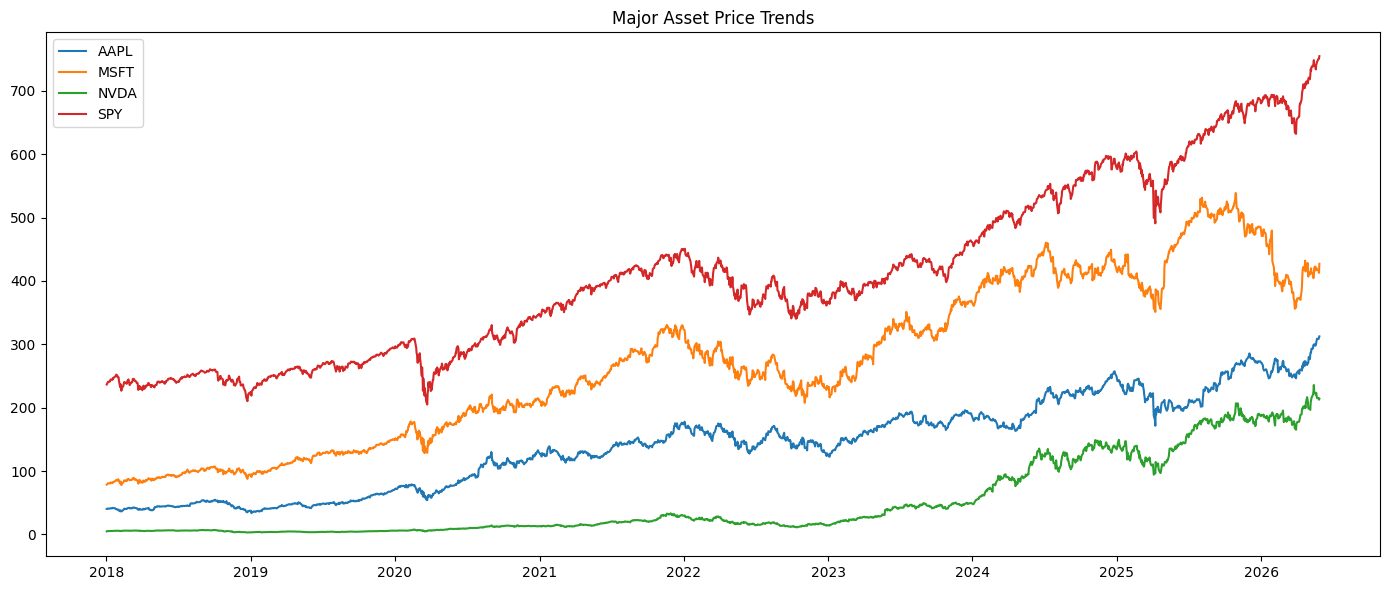

In [107]:
plt.figure(figsize=(14,6))

for asset in major_assets:
    plt.plot(
        adj_close.index,
        adj_close[asset],
        label=asset
    )

plt.title("Major Asset Price Trends")
plt.legend()
plt.tight_layout()
plt.show()

### Normalized Price Comparison

Since assets begin the sample period at different price levels, direct comparison of raw prices can be misleading. By normalizing the price level for all of them, we can make an objective judgment regarding their performance.


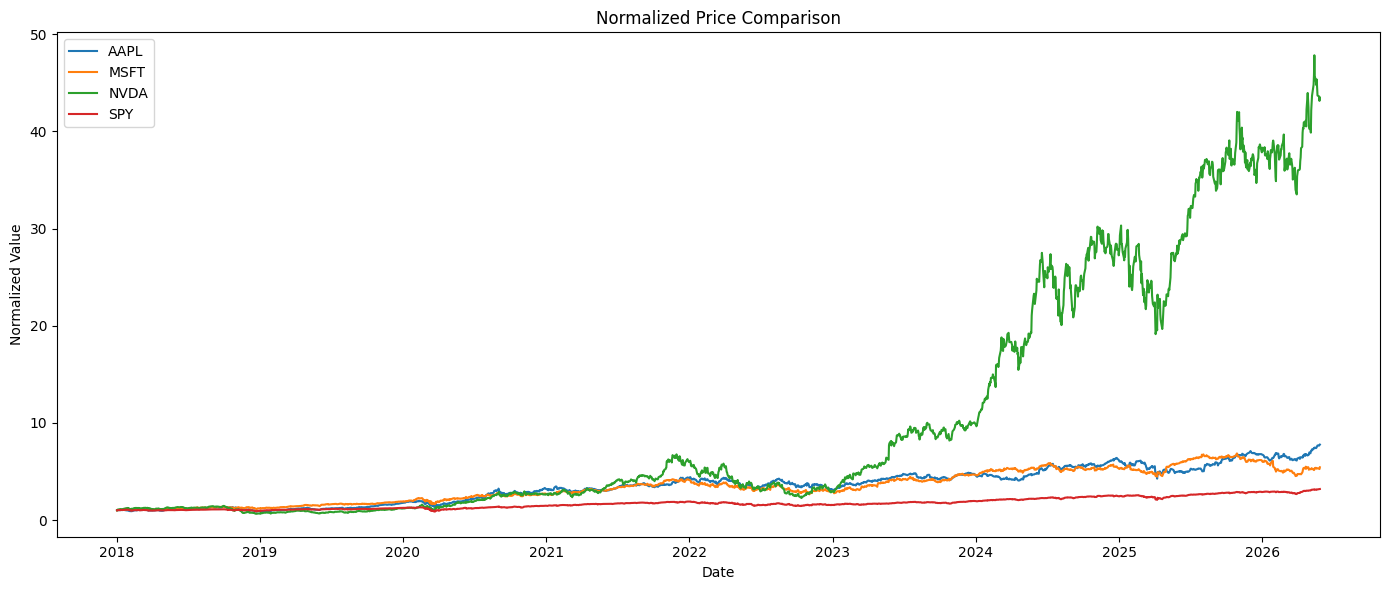

In [106]:

plt.figure(figsize=(14,6))

for asset in major_assets:
    plt.plot(
        normalized_prices.index,
        normalized_prices[asset],
        label=asset
    )

plt.title("Normalized Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Top Performing Assets

Using normalized prices, the final value of each asset represents its cumulative growth relative to the start of the sample period.


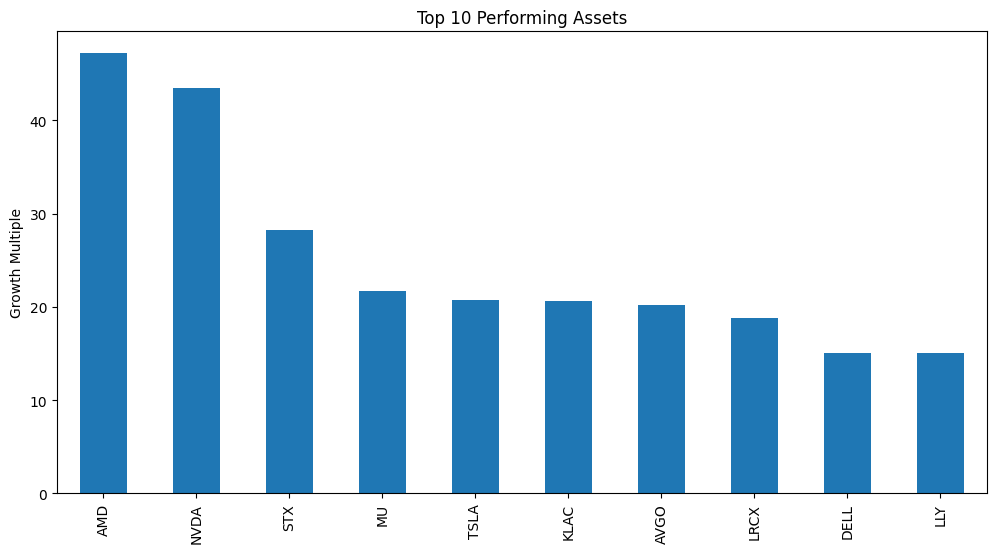

AMD     47.184886
NVDA    43.473704
STX     28.232743
MU      21.683564
TSLA    20.689170
KLAC    20.596416
AVGO    20.229847
LRCX    18.848629
DELL    15.062175
LLY     15.044507
Name: 2026-05-28 00:00:00, dtype: float64


<Figure size 640x480 with 0 Axes>

In [105]:
performance = (
    normalized_prices.iloc[-1]
    .sort_values(ascending=False)
)

top10 = performance.head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title("Top 10 Performing Assets")
plt.ylabel("Growth Multiple")

plt.show()
plt.tight_layout()
print(top10)

Bottom Performing Assets

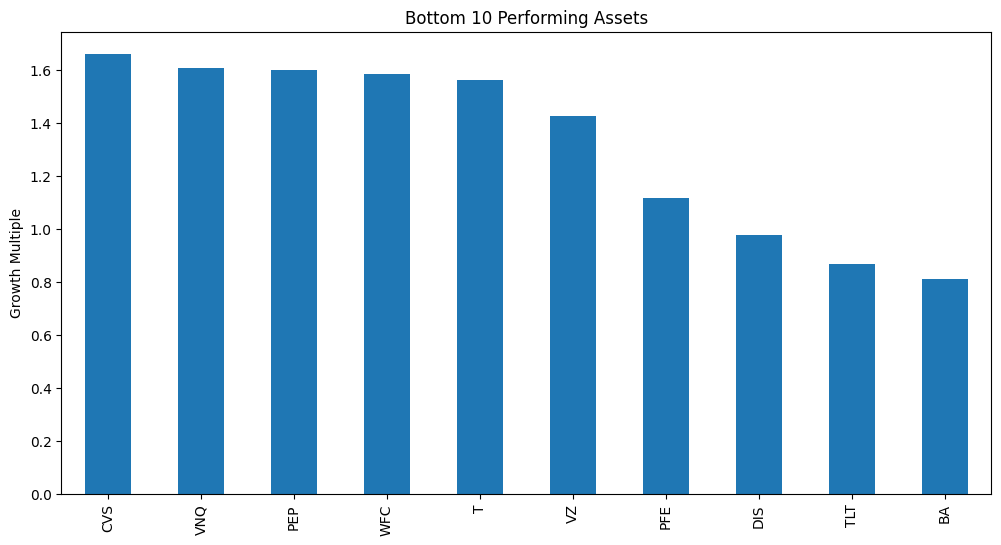

CVS    1.659982
VNQ    1.604594
PEP    1.597004
WFC    1.584439
T      1.562707
VZ     1.424082
PFE    1.115024
DIS    0.976517
TLT    0.865240
BA     0.808734
Name: 2026-05-28 00:00:00, dtype: float64


<Figure size 640x480 with 0 Axes>

In [104]:
bottom10 = performance.tail(10)

plt.figure(figsize=(12,6))

bottom10.plot(kind='bar')

plt.title("Bottom 10 Performing Assets")
plt.ylabel("Growth Multiple")

plt.show()
plt.tight_layout()
print(bottom10)

# 6. Return Analysis

Daily returns are analyzed to understand the performance and risk characteristics of the assets. Unlike raw prices, returns allow meaningful comparison across securities with different price levels.

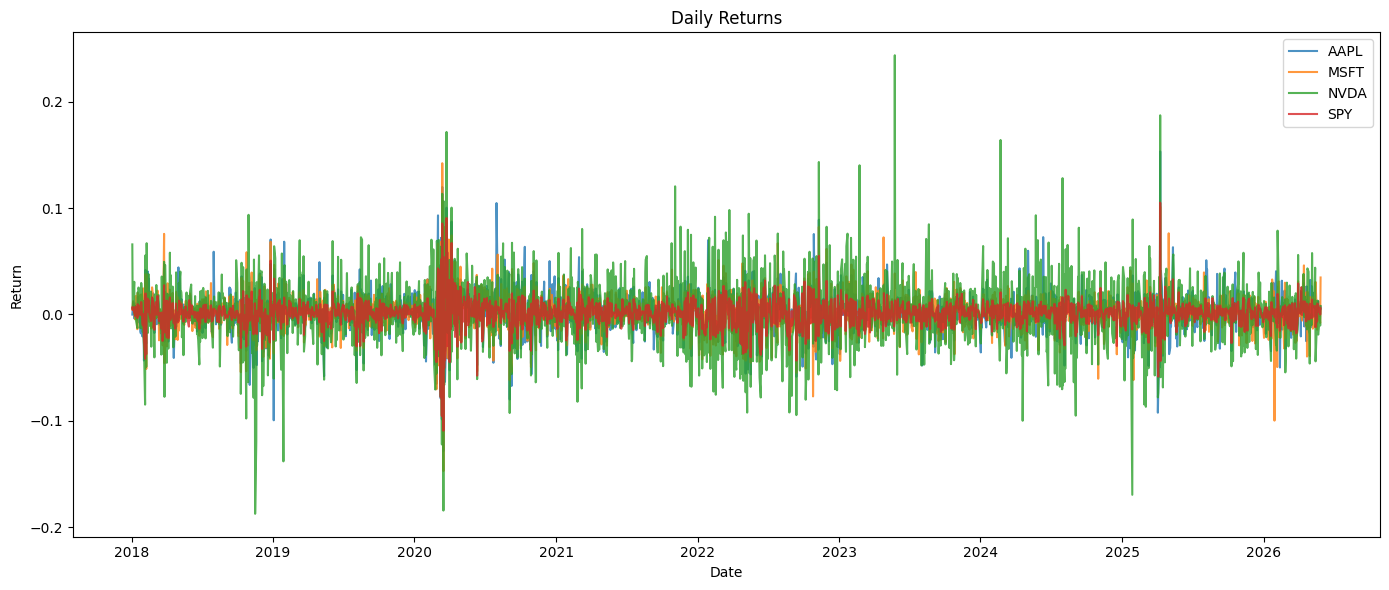

In [102]:
assets = [
    'AAPL',
    'MSFT',
    'NVDA',
    'SPY'
]

plt.figure(figsize=(14,6))

for asset in assets:
    plt.plot(
        returns.index,
        returns[asset],
        label=asset,
        alpha=0.8
    )

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Return Summary Statistics

In [39]:
return_stats = pd.DataFrame({
    'Mean Return': returns.mean(),
    'Volatility': returns.std(),
    'Min Return': returns.min(),
    'Max Return': returns.max()
})

return_stats.head()

,Mean Return,Volatility,Min Return,Max Return
AAPL,0.001155,0.019208,-0.128647,0.153289
ABBV,0.000691,0.016816,-0.162524,0.137673
ABT,0.000375,0.015551,-0.100389,0.109360
ADI,0.001032,0.021625,-0.166149,0.183876
AMAT,0.001461,0.028339,-0.203576,0.161058


In [78]:
log_return_stats = pd.DataFrame({
    'Mean': log_returns.mean(),
    'Volatility': log_returns.std(),
    'Skewness': log_returns.skew(),
    'Kurtosis': log_returns.kurtosis()
})

log_return_stats.head()

,Mean,Volatility,Skewness,Kurtosis
AAPL,0.000971,0.019187,-0.089835,6.200984
ABBV,0.000548,0.016968,-1.280258,14.936847
ABT,0.000254,0.015579,-0.351947,6.832584
ADI,0.000799,0.021599,-0.089504,7.693123
AMAT,0.001057,0.028448,-0.452214,4.138138


## 8. Outlier Detection
To show extreme market moves

In [91]:
z_scores = (
    returns - returns.mean()
) / returns.std()

outliers = (
    z_scores.abs() > 3
)

outliers.sum().sort_values(
    ascending=False
).head(10)

GLW     41
QCOM    40
MRK     39
ISRG    39
AMGN    39
KO      38
JNJ     38
TMUS    38
UNH     37
APH     37
dtype: int64

## 9. Most Volatile Assets

The following assets exhibited the highest return volatility during the sample period, indicating greater price fluctuations and risk.

In [40]:
top_volatility = (
    returns.std()
    .sort_values(ascending=False)
    .head(10)
)

top_volatility

TSLA    0.039498
AMD     0.035360
MU      0.032323
NVDA    0.031921
WDC     0.031737
LRCX    0.029748
INTC    0.029611
ANET    0.029079
DELL    0.028360
AMAT    0.028339
dtype: float64

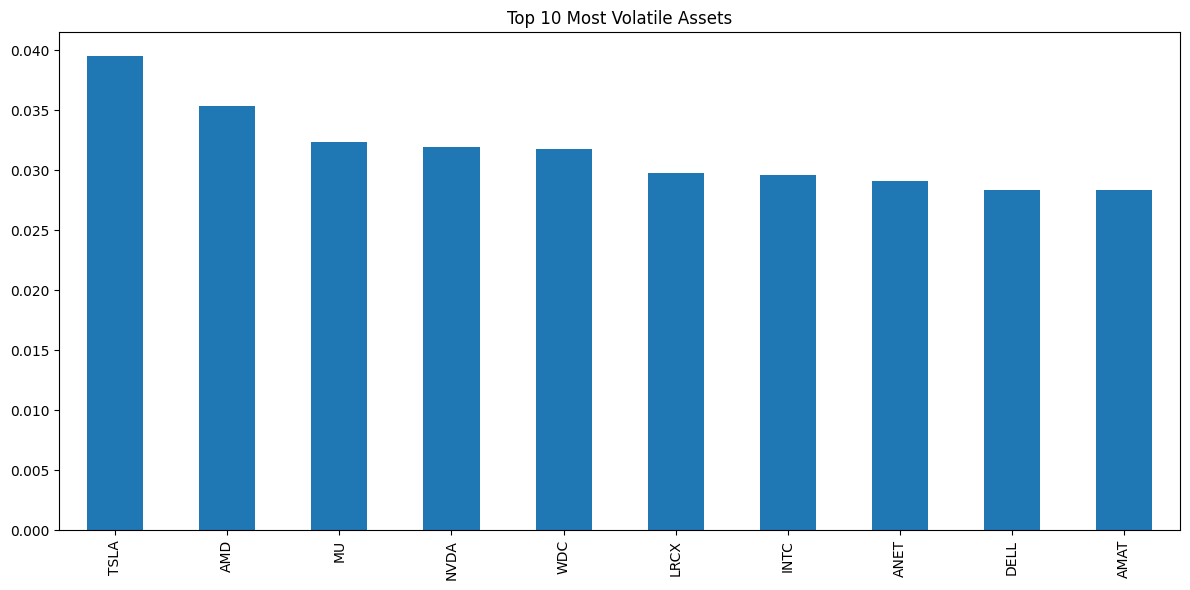

In [100]:
plt.figure(figsize=(12,6))

top_volatility.plot(kind='bar')

plt.title("Top 10 Most Volatile Assets")
plt.tight_layout()
plt.show()

### Least Volatile Assets

The assets below exhibited the lowest return volatility during the sample period, indicating more stable price movements and lower levels of market risk.

In [42]:
low_volatility = (
    returns.std()
    .sort_values()
    .head(10)
)

low_volatility

TLT    0.009773
XLP    0.009804
GLD    0.010467
XLV    0.010975
DIA    0.011840
SPY    0.012104
KO     0.012107
JNJ    0.012252
PG     0.012621
XLU    0.012751
dtype: float64

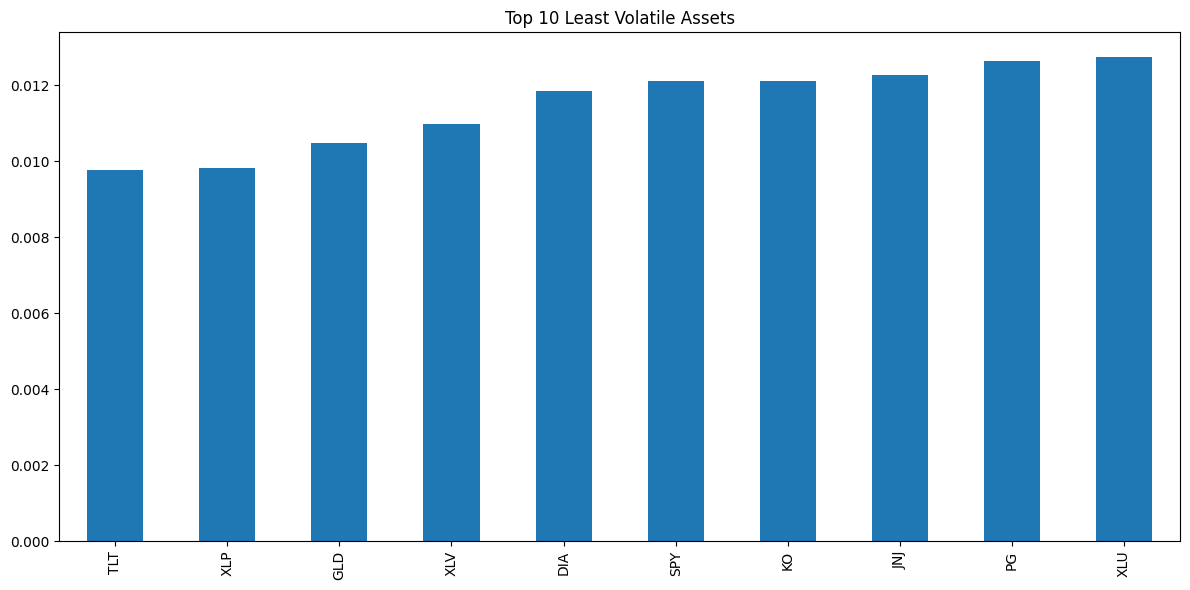

In [99]:
plt.figure(figsize=(12,6))

low_volatility.plot(kind='bar')

plt.title("Top 10 Least Volatile Assets")
plt.tight_layout()
plt.show()

## 10. Rolling Volatility Analysis
It shows 
- Covid crash
- Bear market
- Market Stress periods

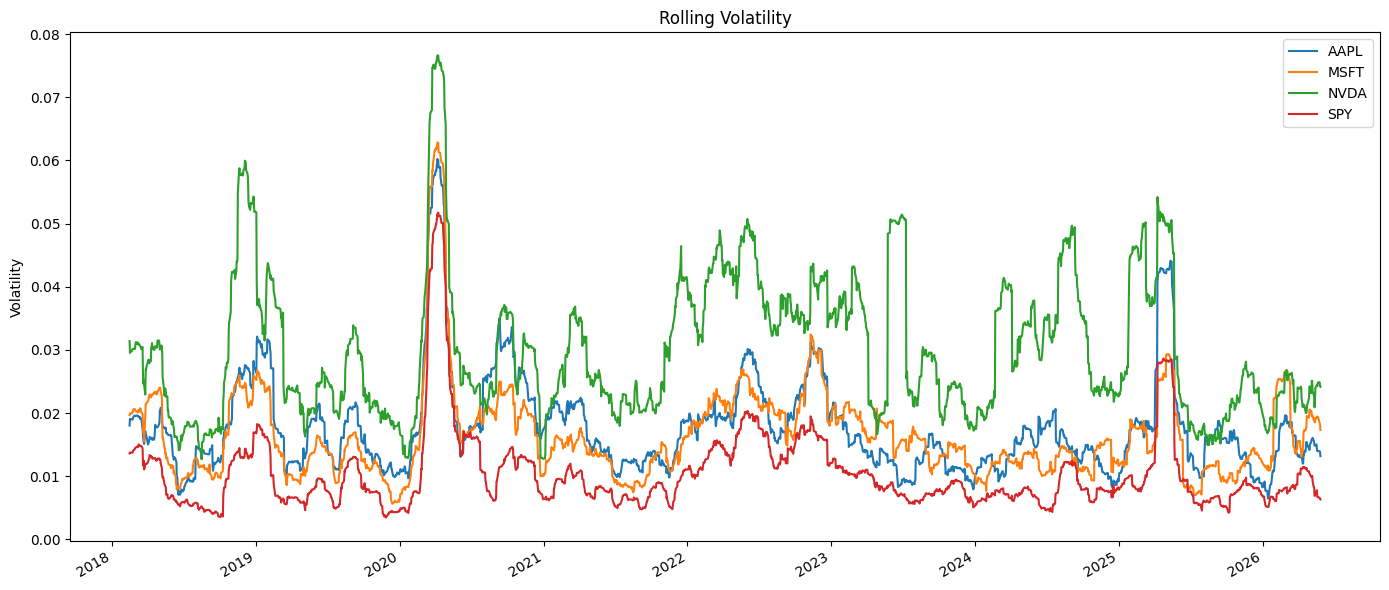

In [98]:
rolling_volatility[
    ['AAPL','MSFT','NVDA','SPY']
].plot(
    figsize=(14,6)
)

plt.title("Rolling Volatility")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

## 11. Return Distribution Analysis

The distribution of returns is examined to understand the frequency of different return outcomes and assess the presence of skewness and extreme market movements.

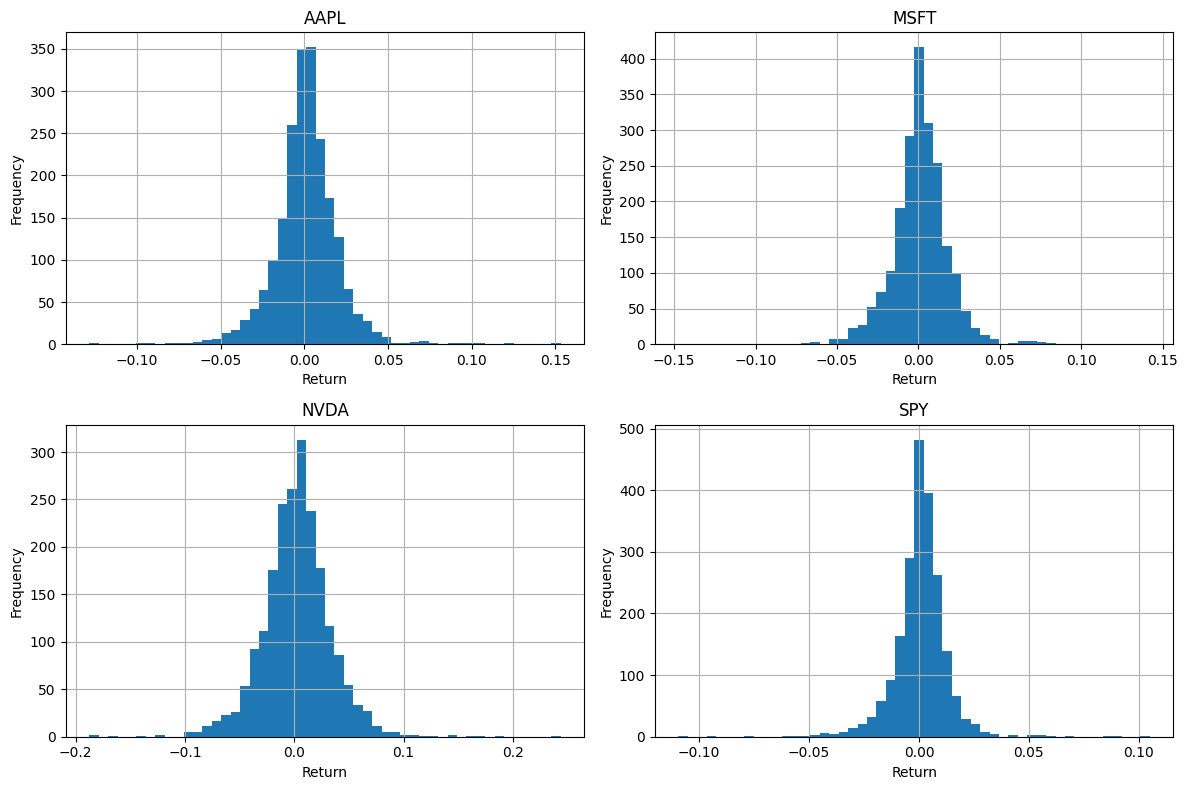

In [81]:
assets = ['AAPL','MSFT','NVDA','SPY']

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, asset in zip(
    axes.flatten(),
    assets
):

    returns[asset].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(asset)
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Skewness and Kurtosis

In [51]:
distribution_stats = pd.DataFrame({
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})

distribution_stats.head()

,Skewness,Kurtosis
AAPL,0.147473,6.426405
ABBV,-0.906974,12.810026
ABT,-0.150064,6.630204
ADI,0.221945,7.718537
AMAT,-0.210553,3.425685


### Assets with Highest Kurtosis

Ranking assets by kurtosis helps identify securities whose return distributions exhibit the strongest tail behavior and the greatest tendency toward extreme return events.

In [52]:
distribution_stats.sort_values(
    'Kurtosis',
    ascending=False
).head(10)

,Skewness,Kurtosis
ORCL,2.207704,35.297607
MCD,0.353949,29.824279
WELL,0.093172,28.024451
CVX,-0.320218,22.957245
UNH,-1.363985,20.749295
VNQ,-1.094270,19.721182
DIA,-0.473555,18.980660
LOW,-0.954809,18.822458
NFLX,-0.877365,18.673132
AXP,1.059377,18.160736


## 13. Correlation Matrix

The correlation matrix summarizes pairwise relationships between asset returns, where values close to 1 indicate strong positive co-movement and values close to -1 indicate strong inverse relationships.

In [53]:
corr_matrix = returns.corr()

corr_matrix.head()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,COF,COP,COST,CRM,CSCO,CVS,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NFLX,NVDA,ORCL,PANW,PEP,PFE,PG,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,SYK,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
AAPL,1.000000,0.279563,0.428778,0.579173,0.546197,0.488910,0.368710,0.583855,0.412451,0.517686,0.514155,0.461709,0.404724,0.435485,0.425063,0.563083,0.516889,0.514891,0.443399,0.393823,0.326121,0.431984,0.303814,0.490968,0.505666,0.531871,0.251469,0.332708,0.387239,0.385722,0.468298,0.688452,0.431437,0.457018,0.348269,0.277475,0.056752,0.465434,0.611266,0.609662,0.487835,0.513589,0.471833,0.394403,0.380984,0.420667,0.545607,0.594713,0.312682,0.427082,0.558703,0.348438,0.488670,0.279836,0.259782,0.473323,0.545675,0.578889,0.391889,0.522416,0.238865,0.283697,0.501780,0.674537,0.447856,0.320149,0.430720,0.563473,0.364114,0.420010,0.398383,0.294437,0.353643,0.488618,0.280965,0.551629,0.807521,0.345260,0.354296,0.521787,0.768443,0.399273,0.456371,0.262839,0.409186,-0.085799,0.465724,0.362246,0.454206,0.566771,0.298162,0.451592,0.569465,0.498095,0.211098,0.398879,0.272884,0.374026,0.333141,0.347706,0.540195,0.582002,0.812032,0.491789,0.353079,0.554210,0.693743,0.291319
ABBV,0.279563,1.000000,0.408244,0.274118,0.254078,0.165326,0.477022,0.171869,0.184154,0.282358,0.199328,0.298146,0.224472,0.313950,0.220016,0.337110,0.403208,0.269482,0.311429,0.285453,0.344896,0.267952,0.286362,0.264158,0.214761,0.353324,0.336377,0.318357,0.285660,0.166764,0.377410,0.463791,0.234322,0.279886,0.228705,0.384066,0.011133,0.299664,0.263885,0.265988,0.293733,0.340793,0.342097,0.222510,0.304361,0.247212,0.301849,0.340530,0.446722,0.324674,0.226617,0.373608,0.356229,0.374414,0.276788,0.315705,0.236737,0.359868,0.321664,0.173804,0.281926,0.445116,0.303139,0.296411,0.204496,0.265844,0.149139,0.190460,0.194375,0.166590,0.379683,0.447402,0.347921,0.319192,0.316037,0.207119,0.332355,0.323242,0.241950,0.317563,0.427094,0.200436,0.395858,0.303384,0.301285,-0.078255,0.363979,0.283844,0.116382,0.295172,0.329670,0.321567,0.381175,0.368546,0.293054,0.200316,0.262467,0.283923,0.250691,0.319615,0.395313,0.393683,0.325455,0.437419,0.322441,0.628944,0.301080,0.279334
ABT,0.428778,0.408244,1.000000,0.396394,0.320535,0.266132,0.438694,0.318521,0.259779,0.362165,0.268685,0.361612,0.281117,0.378271,0.301155,0.488477,0.493242,0.399620,0.337297,0.306358,0.377735,0.321058,0.209935,0.420500,0.368251,0.435173,0.306313,0.286567,0.344081,0.193071,0.554173,0.574679,0.321966,0.352007,0.284001,0.371788,0.071007,0.358194,0.370455,0.372671,0.364064,0.455593,0.449793,0.296905,0.362524,0.275021,0.534689,0.440002,0.531774,0.376435,0.336761,0.445499,0.477150,0.335124,0.335480,0.420175,0.317957,0.492882,0.417887,0.283906,0.312451,0.418159,0.399491,0.462365,0.250229,0.396282,0.250219,0.321460,0.240101,0.259860,0.455794,0.401017,0.466889,0.507247,0.336472,0.304065,0.499370,0.329697,0.328967,0.485160,0.568129,0.235430,0.574137,0.354073,0.367829,-0.091457,0.566777,0.367302,0.190427,0.386759,0.366890,0.403230,0.497902,0.495444,0.345769,0.234480,0.232047,0.315119,0.322121,0.256235,0.485595,0.500147,0.481131,0.563570,0.472349,0.722805,0.444779,0.227795
ADI,0.579173,0.274118,0.396394,1.000000,0.735819,0.549478,0.348972,0.486169,0.440240,0.603745,0.621490,0.536212,0.432176,0.511243,0.484954,0.602986,0.513537,0.533927,0.521675,0.519017,0.337426,0.529954,0.366132,0.412532,0.455684,0.505208,0.279659,0.401964,0.476224,0.450671,0.466311,0.678831,0.466763,0.566720,0.418995,0.269442,0.087604,0.552766,0.532053,0.534662,0.555609,0.512066,0.521546,0.439736,0.382894,0.534360,0.539279,0.688907,0.257323,0.507918,0.736425,0.289046,0.506431,0.235191,0.213942,0.481667,0.726109,0.538801,0.361262,0.457371,0.186860,0.249272,0.567157,0.555710,0.623961,0.283080,0.345818,0.597487,0.354

### Correlation Heatmap

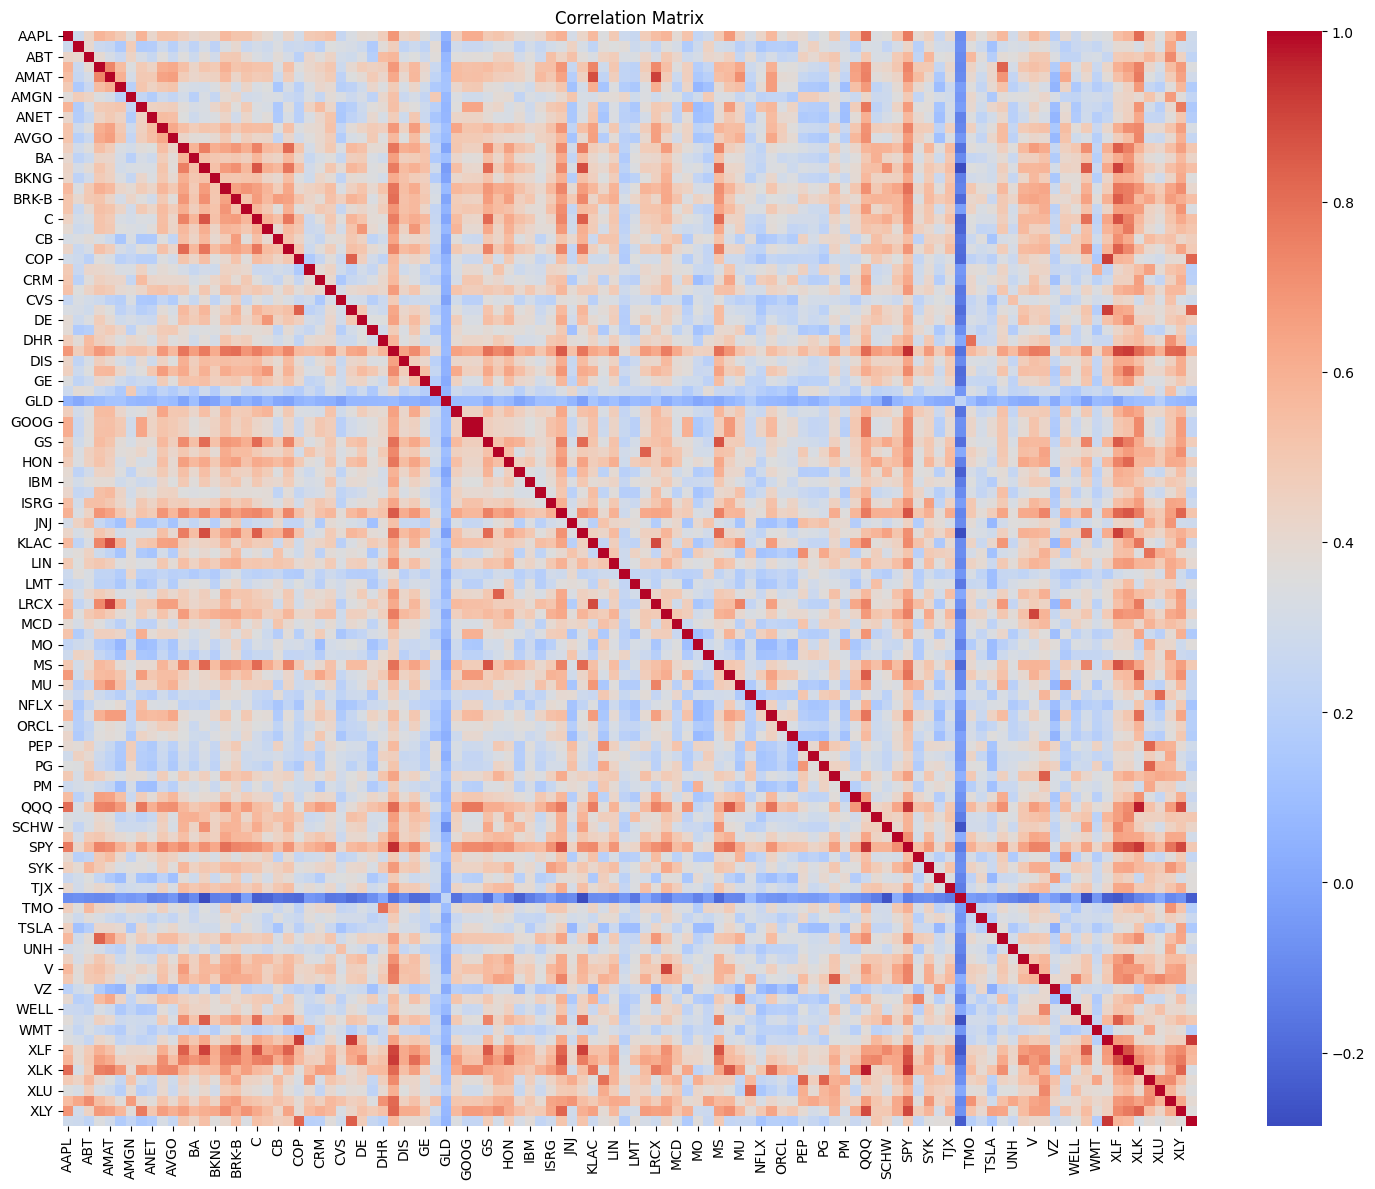

In [97]:
plt.figure(figsize=(15,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:

# Upper triangle only to avoid duplicates
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = (
    upper
    .unstack()
    .dropna()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

GOOGL  GOOG    0.995720
XLK    QQQ     0.974428
SPY    DIA     0.945420
       QQQ     0.937784
XLK    SPY     0.931159
XOM    XLE     0.926532
XLI    DIA     0.924217
XLE    CVX     0.918030
       COP     0.917625
XLF    JPM     0.911713
LRCX   AMAT    0.910939
XLF    BAC     0.906172
V      MA      0.902934
XLF    DIA     0.900267
XLY    SPY     0.898398
       QQQ     0.887059
LRCX   KLAC    0.886370
KLAC   AMAT    0.883633
XLI    SPY     0.882093
JPM    BAC     0.881552
dtype: float64

## 14. Annual Return

In [83]:
annual_return = returns.mean() * 252

annual_return.sort_values(
    ascending=False
).head(10)

AMD     0.616213
NVDA    0.578833
TSLA    0.557381
MU      0.498800
STX     0.487290
LRCX    0.462040
KLAC    0.457463
AVGO    0.444329
DELL    0.424386
WDC     0.395854
dtype: float64

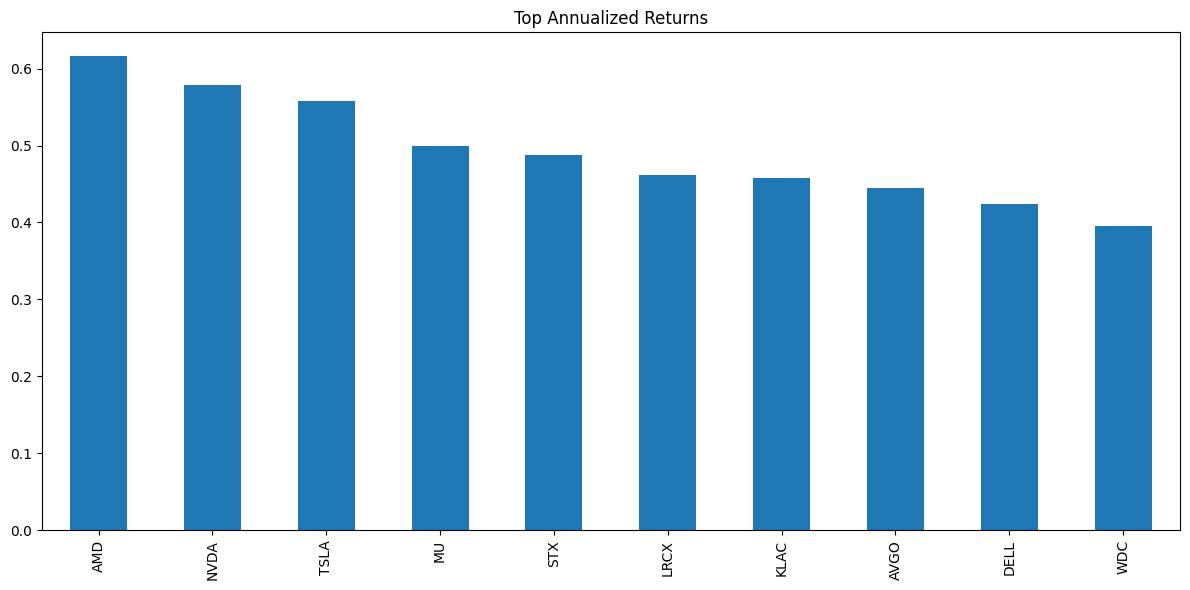

In [96]:
annual_return.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Top Annualized Returns"
)
plt.tight_layout()
plt.show()

## 15. Final Summary

In [109]:
corr_unstacked = corr_matrix.where(
    ~np.eye(corr_matrix.shape[0], dtype=bool)
).stack()

top_pair = corr_unstacked.idxmax()
top_corr = corr_unstacked.max()
annual_volatility = returns.std() * np.sqrt(252)

best_asset = annual_return.idxmax()
worst_asset = annual_return.idxmin()

most_volatile_asset = annual_volatility.idxmax()
least_volatile_asset = annual_volatility.idxmin()

final_summary = pd.DataFrame({
    "Metric": [
        "Number of Assets",
        "Analysis Period (Days)",
        "Average Daily Return",
        "Average Annualized Return",
        "Average Annualized Volatility",
        "Highest Correlation Pair",
        "Highest Correlation Value",
        "Best Performing Asset",
        "Worst Performing Asset",
        "Most Volatile Asset",
        "Least Volatile Asset"
    ],
    "Value": [
        returns.shape[1],
        len(returns),
        round(returns.mean().mean(), 6),
        round(annual_return.mean(), 4),
        round(annual_volatility.mean(), 4),
        f"{top_pair[0]} - {top_pair[1]}",
        round(top_corr, 4),
        best_asset,
        worst_asset,
        most_volatile_asset,
        least_volatile_asset
    ]
})

final_summary

,Metric,Value
0,Number of Assets,108
1,Analysis Period (Days),2111
2,Average Daily Return,0.000817
3,Average Annualized Return,0.206
4,Average Annualized Volatility,0.309
5,Highest Correlation Pair,GOOG - GOOGL
6,Highest Correlation Value,0.9957
7,Best Performing Asset,AMD
8,Worst Performing Asset,TLT
9,Most Volatile Asset,TSLA
